In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [24]:
def sor_cluster_oldu(u, w, clusters, max_iter = 10000, tol = 1e-5):
    '''Successive Over-Relaxation method for laplace equation'''
    n, m = u.shape
    
    # Set boundary conditions 
    u[0, :] = 0  # Top boundary
    u[-1, :] = 1  # Bottom boundary
    if clusters is not None:
        for (x, y) in clusters:
            u[x, y] = 0 


    errors = []
    for it in range(max_iter):
        u_old = u.copy()
        # Update each interior point
        for i in range(1, n - 1):
            for j in range(m):
                if clusters is not None and (i, j) in clusters:
                    continue  # Skip cluster points
                jr = (j + 1) % m  # right boundary
                jl = (j - 1) % m  # left boundary
                u[i, j] = 0.25 * w * (u[i+1, j] + u[i-1, j] + u[i, jr] + u[i, jl]) + (1 -w) * u[i, j]
        u[0, :] = 0  # Top boundary
        u[-1, :] = 1  # Bottom boundary
        if clusters is not None:
            for (x, y) in clusters:
                u[x, y] = 0  

        errors.append(np.max(np.abs(u - u_old)))
        # Check for convergence
        if np.max(np.abs(u - u_old)) < tol:
            return u, errors,it
            
    
    return u, errors,max_iter

In [25]:
def plot_heatmap(arr, title="Heatmap", show=True):
    fig, ax = plt.subplots(figsize=(6, 4), dpi=200)

    im = ax.imshow(
        arr,
        origin="lower",
        extent=[0, 1, 0, 1],
        aspect="auto",
        cmap="plasma",   # same colormap
        vmin=0,          # same min
        vmax=1           # same max
    )

    fig.colorbar(im, ax=ax, label="Concentration")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_title(title)

    plt.tight_layout()
    if show:
        plt.show()
    plt.close(fig)

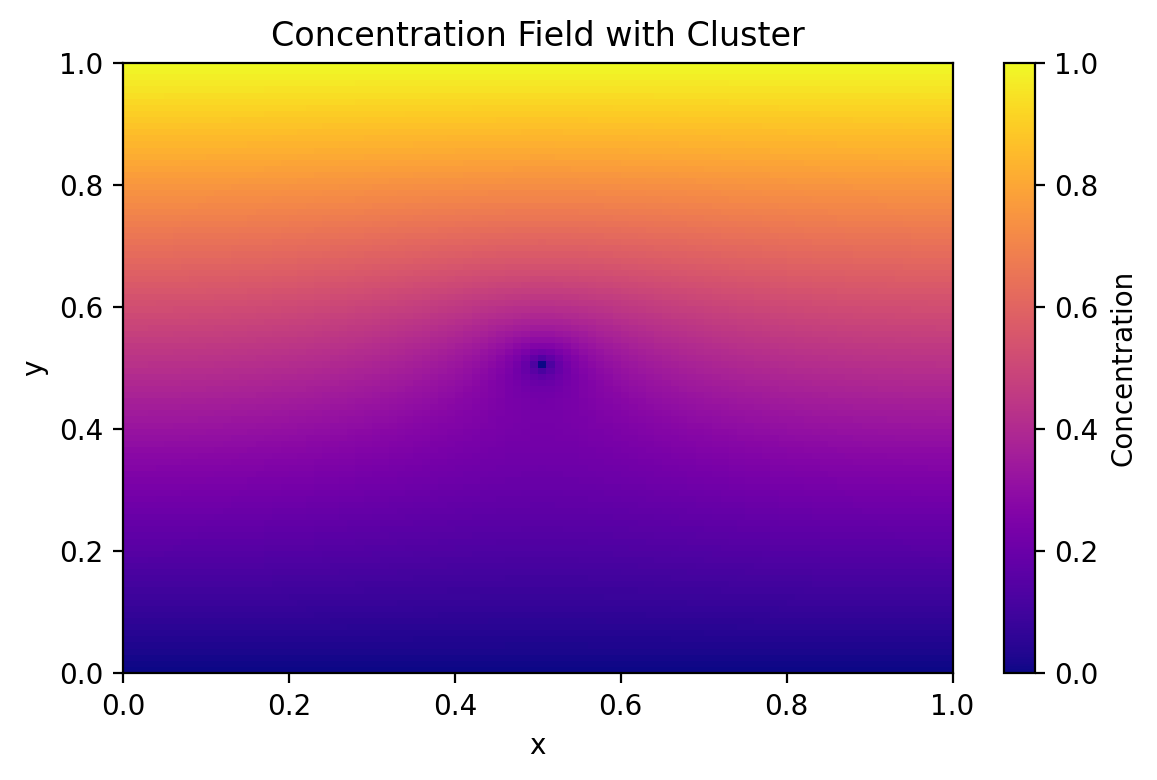

In [26]:
u, errors, it = sor_cluster_oldu(np.zeros((100, 100)), w=1.5, clusters=[(50, 50)], max_iter=10000, tol=1e-5)
plot_heatmap(u, title="Concentration Field with Cluster")

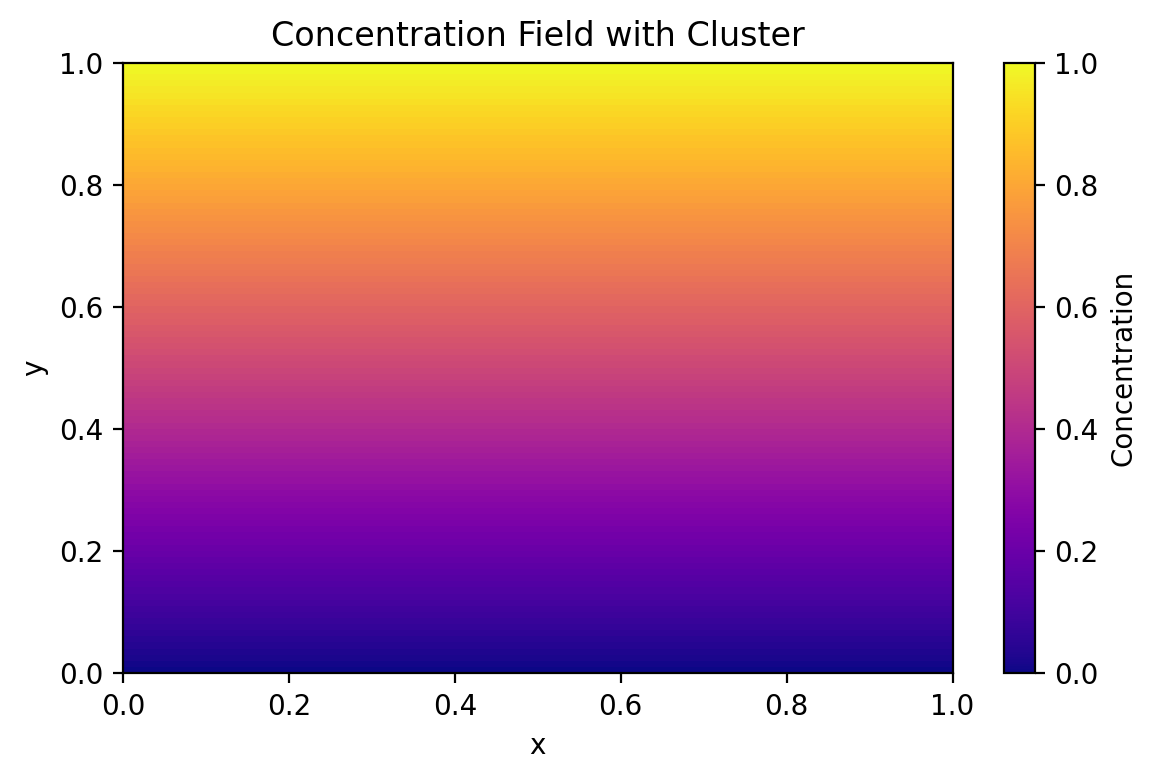

In [27]:
y = np.linspace(0, 1, 100)
u = np.tile(y[:, None], (1, 100))
plot_heatmap(u, title="Concentration Field with Cluster")

In [28]:
def find_growth_candidates(clusters, n, m):
    candidates = set()
    for (x, y) in clusters:
        yl = (y - 1) % m
        yr = (y + 1) % m
        
        candidates.add((x, yr))  # right
        candidates.add((x, yl))  # left
        if x+1 < n:
            candidates.add((x + 1, y))  # down
        if x-1 >= 0:
            candidates.add((x - 1, y))  # up
    return candidates - clusters

### DLA function

In [40]:
def DLA(n,m,eta,max_particles = 1000,w = 1.8):
    clusters = set([(1, m//2)])  # Start with a seed in the center
    assert eta > 0, "eta must be positive"
    assert 1<= w < 2, "w must be in the range (1, 2)"
    y = np.linspace(0, 1, n)
    concentration = np.tile(y[:, None], (1, m))  # Initial concentration field
    its = []
    for particle_count in range(max_particles):
        concentration,_,it = sor_cluster_oldu(concentration, w, clusters)
        its.append(it)
        candidates = list(find_growth_candidates(clusters, n, m))
        p_candidates = {}
        sum_c = sum(max(concentration[c],0)**eta for c in candidates)
        for candidate in candidates:
            c_value = max(concentration[candidate],0)  # Ensure non-negative
            if sum_c == 0:
                p_candidates[candidate] = 1/len(candidates)
            else:
                p_candidates[candidate] = (c_value**eta) / sum_c
        new_particle_i = np.random.choice(len(p_candidates.keys()), p=list(p_candidates.values()))
        new_particle = list(p_candidates.keys())[new_particle_i]
        if new_particle[0] == n - 1:
            return clusters,its,concentration,particle_count
        clusters.add(new_particle)
    return clusters,its,concentration,max_particles

### DLA with $\eta$ = 0.5

Mean iterations: 33.129
Particle count: 1000


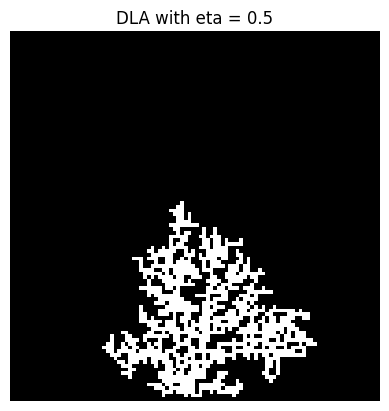

In [41]:
eta1 = 0.5
clusters, its, concentration, particle_count = DLA(100, 100, eta=eta1, max_particles=1000)
print("Mean iterations:", np.mean(its))
print("Particle count:", particle_count)
grid = np.zeros((100, 100))
for (x, y) in clusters:
    grid[x, y] = 1
plt.imshow(grid, origin='lower', cmap='gray')
plt.axis("off")
plt.title("DLA with eta = " + str(eta1))
plt.show()  


### DLA with $\eta$ = 1

Mean iterations: 52.055
Particle count: 1000


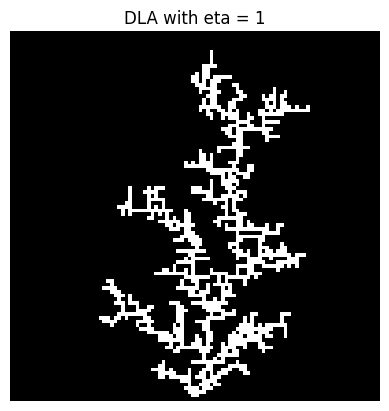

In [44]:
eta2 = 1
clusters, its, concentration, particle_count = DLA(100, 100, eta=eta2, max_particles=1500)
print("Mean iterations:", np.mean(its))
print("Particle count:", particle_count)
grid = np.zeros((100, 100))
for (x, y) in clusters:
    grid[x, y] = 1
plt.imshow(grid, origin='lower', cmap='gray')
plt.axis("off")
plt.title("DLA with eta = " + str(eta2))
plt.show()  


### DLA with $\eta$ = 1.5

Mean iterations: 72.26003490401396
Particle count: 572


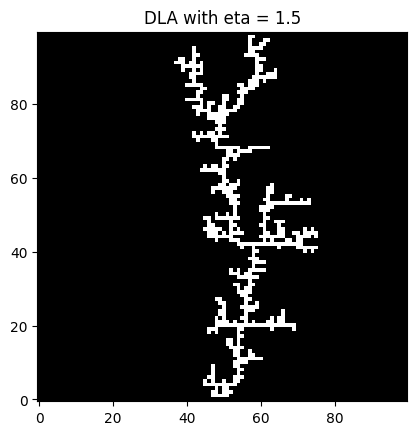

In [43]:
eta3 = 1.5
clusters, its, concentration, particle_count = DLA(100, 100, eta=eta3, max_particles=1000)
print("Mean iterations:", np.mean(its))
print("Particle count:", particle_count)
grid = np.zeros((100, 100))
for (x, y) in clusters:
    grid[x, y] = 1
plt.imshow(grid, origin='lower', cmap='gray')
plt.axis("off")
plt.title("DLA with eta = " + str(eta3))
plt.show()  

### Optimal $\omega$ in DLA

#### $\eta$ = 0.5

In [58]:
omegas = np.linspace(1.70, 1.90, 21)
min_it = 100000
for omega in omegas:
    _,it,_,_ = DLA(100, 100, eta=0.5, max_particles=50, w=omega)
    if np.mean(it) < min_it:
        min_it = np.mean(it)
        best_omega = omega
print("Best omega:", best_omega, "with mean iterations:", min_it)

Best omega: 1.78 with mean iterations: 27.44


#### $\eta$ = 1

In [59]:
omegas = np.linspace(1.70, 1.90, 21)
min_it = 100000
for omega in omegas:
    _,it,_,_ = DLA(100, 100, eta=1, max_particles=50, w=omega)
    if np.mean(it) < min_it:
        min_it = np.mean(it)
        best_omega = omega
print("Best omega:", best_omega, "with mean iterations:", min_it)

Best omega: 1.74 with mean iterations: 38.32


#### $\eta$ = 1.5

In [60]:
omegas = np.linspace(1.70, 1.90, 21)
min_it = 100000
for omega in omegas:
    _,it,_,_ = DLA(100, 100, eta=1.5, max_particles=50, w=omega)
    if np.mean(it) < min_it:
        min_it = np.mean(it)
        best_omega = omega
print("Best omega:", best_omega, "with mean iterations:", min_it)

Best omega: 1.8599999999999999 with mean iterations: 50.72


### Parallel with red-black SOR

In [54]:
from numba import prange, njit

In [71]:
@njit(parallel=True)
def sor_step(u, w, mask, color):  # color: 0 for red, 1 for black
    n, m = u.shape
    rowmax = np.zeros(n, dtype=np.float64)

    # update interior rows; columns periodic
    for i in prange(1, n - 1):
        local_max = 0.0
        for j in range(m):
            if ((i + j) & 1) != color:
                continue
            if mask[i, j]:
                continue

            jr = (j + 1) % m
            jl = (j - 1) % m
            
            old = u[i, j]
            new = 0.25 * w * (u[i + 1, j] + u[i - 1, j] + u[i, jr] + u[i, jl]) + (1.0 - w) * old
            u[i, j] = new

            d = abs(new - old)
            if d > local_max:
                local_max = d

        rowmax[i] = local_max

    return np.max(rowmax)


def sor_cluster_parallel(u, w, clusters, max_iter=10000, tol=1e-5):
    #Parallelizable Red-Black SOR
    n, m = u.shape

    # mask of fixed (cluster) points
    mask = np.zeros((n, m), dtype=np.bool_)
    if clusters is not None:
        for (x, y) in clusters:
            if 0 <= x < n and 0 <= y < m:
                mask[x, y] = True

    errors = []

    for it in range(max_iter):
        # enforce BC + obstacles
        u[0, :] = 0.0
        u[-1, :] = 1.0
        u[mask] = 0.0

        # red then black
        d0 = sor_step(u, w, mask, 0)
        # re-enforce fixed points (cheap safety)
        u[0, :] = 0.0
        u[-1, :] = 1.0
        u[mask] = 0.0

        d1 = sor_step(u, w, mask, 1)

        err = d0 if d0 > d1 else d1
        errors.append(err)

        if err < tol:
            return u, errors, it

    return u, errors, max_iter

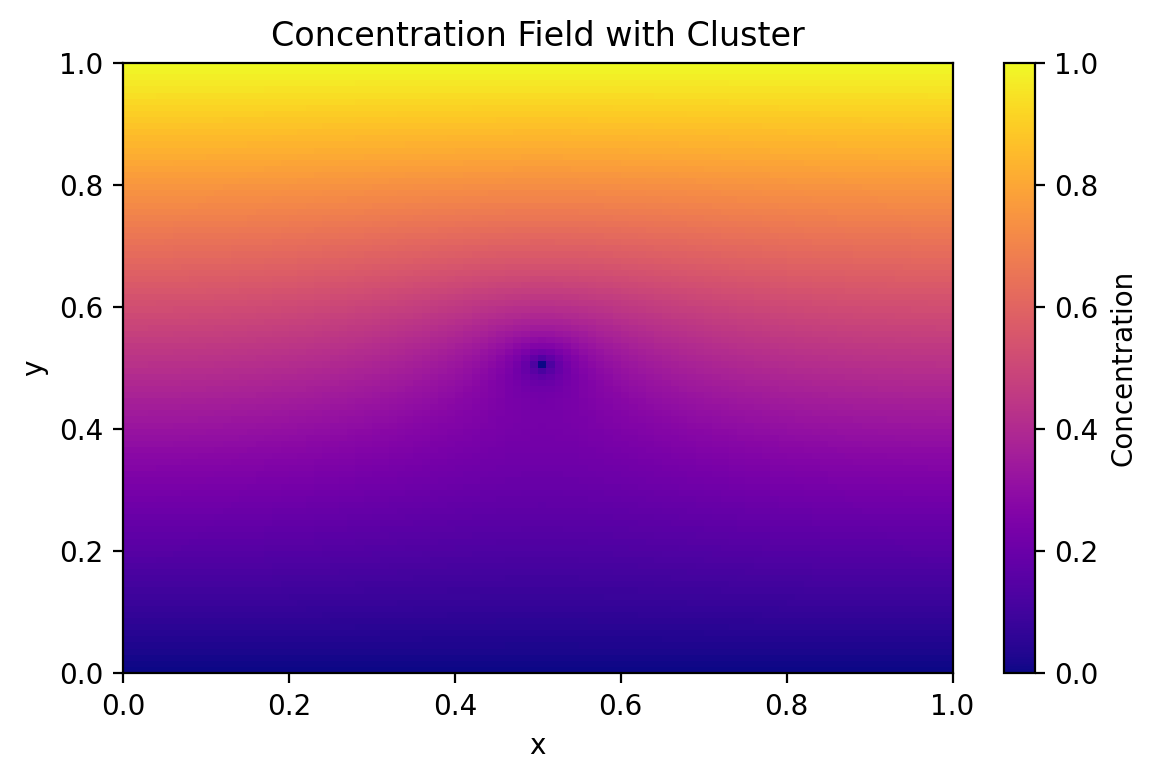

In [79]:
u, errors, it = sor_cluster_parallel(np.zeros((100, 100)), w=1.5, clusters=[(50, 50)], max_iter=10000, tol=1e-5)
plot_heatmap(u, title="Concentration Field with Cluster")


In [73]:
def DLA_rb(n,m,eta,max_particles = 1000,w = 1.8):
    clusters = set([(1, m//2)])  # Start with a seed in the center
    assert eta > 0, "eta must be positive"
    assert 1<= w < 2, "w must be in the range (1, 2)"
    y = np.linspace(0, 1, n)
    concentration = np.tile(y[:, None], (1, m))  # Initial concentration field
    its = []
    for particle_count in range(max_particles):
        concentration,_,it = sor_cluster_parallel(concentration, w, clusters)
        its.append(it)
        candidates = list(find_growth_candidates(clusters, n, m))
        p_candidates = {}
        sum_c = sum(max(concentration[c],0)**eta for c in candidates)
        for candidate in candidates:
            c_value = max(concentration[candidate],0)  # Ensure non-negative
            if sum_c == 0:
                p_candidates[candidate] = 1/len(candidates)
            else:
                p_candidates[candidate] = (c_value**eta) / sum_c
        new_particle_i = np.random.choice(len(p_candidates.keys()), p=list(p_candidates.values()))
        new_particle = list(p_candidates.keys())[new_particle_i]
        if new_particle[0] == n - 1:
            return clusters,its,concentration,particle_count
        clusters.add(new_particle)
    return clusters,its,concentration,max_particles

Mean iterations: 49.92467532467533
Particle count: 1154


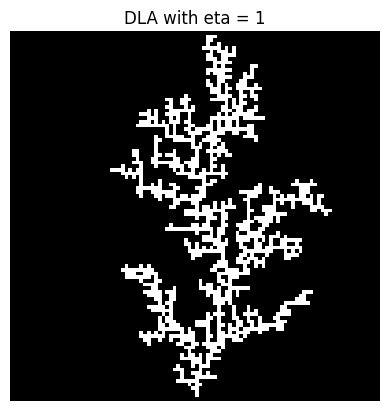

In [78]:
eta3 = 1
clusters, its, concentration, particle_count = DLA_rb(100, 100, eta=eta3, max_particles=2000)
print("Mean iterations:", np.mean(its))
print("Particle count:", particle_count)
grid = np.zeros((100, 100))
for (x, y) in clusters:
    grid[x, y] = 1
plt.imshow(grid, origin='lower', cmap='gray')
plt.axis("off")
plt.title("DLA with eta = " + str(eta3))
plt.show()  

In [75]:
omegas = np.linspace(1.70, 1.90, 21)
min_it = 100000
for omega in omegas:
    _,it,_,_ = DLA_rb(100, 100, eta=0.5, max_particles=50, w=omega)
    if np.mean(it) < min_it:
        min_it = np.mean(it)
        best_omega = omega
print("Best omega:", best_omega, "with mean iterations:", min_it)

Best omega: 1.74 with mean iterations: 30.52


In [76]:
omegas = np.linspace(1.70, 1.90, 21)
min_it = 100000
for omega in omegas:
    _,it,_,_ = DLA_rb(100, 100, eta=1, max_particles=50, w=omega)
    if np.mean(it) < min_it:
        min_it = np.mean(it)
        best_omega = omega
print("Best omega:", best_omega, "with mean iterations:", min_it)

Best omega: 1.8699999999999999 with mean iterations: 45.34


In [77]:
omegas = np.linspace(1.70, 1.90, 21)
min_it = 100000
for omega in omegas:
    _,it,_,_ = DLA_rb(100, 100, eta=1.5, max_particles=50, w=omega)
    if np.mean(it) < min_it:
        min_it = np.mean(it)
        best_omega = omega
print("Best omega:", best_omega, "with mean iterations:", min_it)

Best omega: 1.71 with mean iterations: 56.3
